# EDA before Adding Numerical Features

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as colors


colors = sns.color_palette("PuRd", 2)

# Assign them to classes in a fixed order
PALETTE = {
    "unknown": colors[0],
    "meteor": colors[1]
}
months_map = {1: "january", 2: "february", 3: "march", 4: "april", 5: "may", 6: "june", 7: "july", 8: "august", 9: "september", 10: "october", 11: "november", 12: "december"}


## KPIs (computed on the cluster)

#### SUMIMG KPIs
| class   | mean      | median    | p5        | p95       | dynamic_range | contrast |
|---------|-----------|-----------|-----------|-----------|----------------|----------|
| meteor  | 16.477293 | 16.312372 | 13.303339 | 20.073339 | 79.935432      | 0.150936 |
| unknown | 19.620398 | 19.210514 | 14.982931 | 25.431936 | 69.898804      | 0.187156 |

#### CROP KPIs
| class   | mean      | median    | p5        | p95       | dynamic_range | contrast |
|---------|-----------|-----------|-----------|-----------|----------------|----------|
| meteor  | 17.310854 | 16.219738 | 11.932522 | 24.452929 | 102.720222     | 0.369318 |
| unknown | 22.070200 | 20.662121 | 14.527901 | 34.327068 | 93.092224      | 0.323206 |

## Distributions

In [5]:
dataset = pd.read_csv("data/dataset_51700.csv", sep=";")
dataset.head(3)

,filename,year,month,day,hour,minute,lng,lat,alt,camera,width,height,frames,fps,time,mean_brightness,class,bmin,bmax
0,M20231010_005031_MasLaRoca_NE,2023,10,10,0,50,2.19,41.56,570.0,NE,140.5,91.0,63.0,25,0.08,40.0,meteor,36,43
1,M20231010_005032_MasLaRoca_E,2023,10,10,0,50,2.19,41.91,570.0,E,135.2,116.9,63.0,25,0.08,64.0,meteor,60,72
2,M20231010_005546_MasLaRoca_E,2023,10,10,0,55,2.19,41.91,570.0,E,149.8,128.7,66.0,25,0.20,66.2,meteor,45,86


First, lets select only the features we will need:

In [6]:
features_df = dataset[["filename", "day", "year", "month", "time", "width", "height", "mean_brightness", "bmin", "bmax", "class", "camera"]]
features_df.head(3)

,filename,day,year,month,time,width,height,mean_brightness,bmin,bmax,class,camera
0,M20231010_005031_MasLaRoca_NE,10,2023,10,0.08,140.5,91.0,40.0,36,43,meteor,NE
1,M20231010_005032_MasLaRoca_E,10,2023,10,0.08,135.2,116.9,64.0,60,72,meteor,E
2,M20231010_005546_MasLaRoca_E,10,2023,10,0.20,149.8,128.7,66.2,45,86,meteor,E


In [7]:
features_df.describe()

,day,year,month,time,width,height,mean_brightness,bmin,bmax
count,51700.000000,51700.000000,51700.000000,51700.000000,51700.000000,51700.000000,51700.000000,51700.000000,51700.000000
mean,15.958994,2024.816770,8.018781,0.776258,173.106130,145.220779,74.130832,51.983288,94.380309
std,8.216091,0.867777,4.086898,2.850378,158.225364,120.280207,34.755033,23.405351,49.629173
min,1.000000,2023.000000,1.000000,0.040000,29.000000,5.000000,11.000000,10.000000,11.000000
25%,10.000000,2024.000000,3.000000,0.040000,72.000000,70.000000,49.258220,39.000000,57.000000
50%,15.000000,2025.000000,10.000000,0.160000,127.000000,102.000000,63.454545,45.000000,78.000000
75%,23.000000,2025.000000,11.000000,0.520000,177.300000,159.000000,89.400000,58.000000,121.000000
max,31.000000,2026.000000,12.000000,113.680000,720.000000,576.000000,255.000000,255.000000,255.000000


In [8]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51700 entries, 0 to 51699
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   filename         51700 non-null  object 
 1   day              51700 non-null  int64  
 2   year             51700 non-null  int64  
 3   month            51700 non-null  int64  
 4   time             51700 non-null  float64
 5   width            51700 non-null  float64
 6   height           51700 non-null  float64
 7   mean_brightness  51700 non-null  float64
 8   bmin             51700 non-null  int64  
 9   bmax             51700 non-null  int64  
 10  class            51700 non-null  object 
 11  camera           51700 non-null  object 
dtypes: float64(4), int64(5), object(3)
memory usage: 4.7+ MB


In [9]:
features_df['day'] = features_df['day'].astype('int')
features_df['month'] = features_df['month'].astype('int')
features_df['year'] = features_df['year'].astype('int')
features_df['width'] = features_df['width'].astype('int')
features_df['height'] = features_df['height'].astype('int')

C:\Users\auror\AppData\Local\Temp\ipykernel_19368\1572524009.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features_df['day'] = features_df['day'].astype('int')
C:\Users\auror\AppData\Local\Temp\ipykernel_19368\1572524009.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features_df['month'] = features_df['month'].astype('int')
C:\Users\auror\AppData\Local\Temp\ipykernel_19368\1572524009.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

Now, we will take a look at the distribution of each variable:

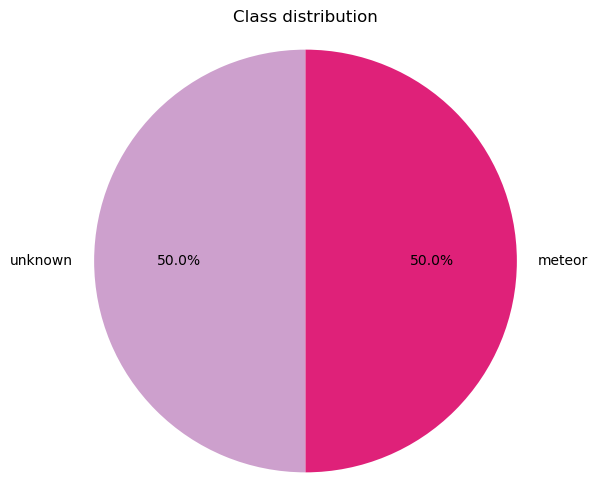

In [10]:
import matplotlib.pyplot as plt

# Count each class
counts = features_df["class"].value_counts()
labels = counts.index
sizes = counts.values

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=[PALETTE[c] for c in labels]  # optional if PALETTE maps class→color
)

ax.set_title("Class distribution")
ax.axis("equal")  # makes the pie circular

plt.show()


In [11]:
num_meteors_2023_2025 = len(features_df[
    (features_df['year'] == 2023) |
    (features_df['year'] == 2024) |
    ((features_df['year'] == 2025) & (features_df['month'] < 10)) |
    ((features_df['year'] == 2025) & (features_df['month'] == 10) & (features_df['day'] <= 3))])

print("# meteors (meteor-only recordings): ", num_meteors_2023_2025)

num_meteors_2025_2026 = len(features_df[
    ((features_df['year'] == 2025) & (features_df['month'] == 10) & (features_df['day'] > 3) & (features_df['class'] == 'meteor')) | 
    ((features_df['year'] == 2025) & (features_df['month'] > 10) & (features_df['class'] == 'meteor')) | 
    (features_df['year'] == 2026) & (features_df['class'] == 'meteor')])

print("# meteors (all recordings): ", num_meteors_2025_2026)

num_nonmeteors_2025_2026 = len(features_df[
    ((features_df['year'] == 2025) & (features_df['month'] == 10) & (features_df['day'] > 3) & (features_df['class'] == 'unknown')) | 
    ((features_df['year'] == 2025) & (features_df['month'] > 10) & (features_df['class'] == 'unknown')) | 
    (features_df['year'] == 2026) & (features_df['class'] == 'unknown')])

print("# non-meteors (all recordings): ", num_nonmeteors_2025_2026)

# meteors (meteor-only recordings):  20212
# meteors (all recordings):  5637
# non-meteors (all recordings):  25851


Look at each variable against the class (continuous variables)

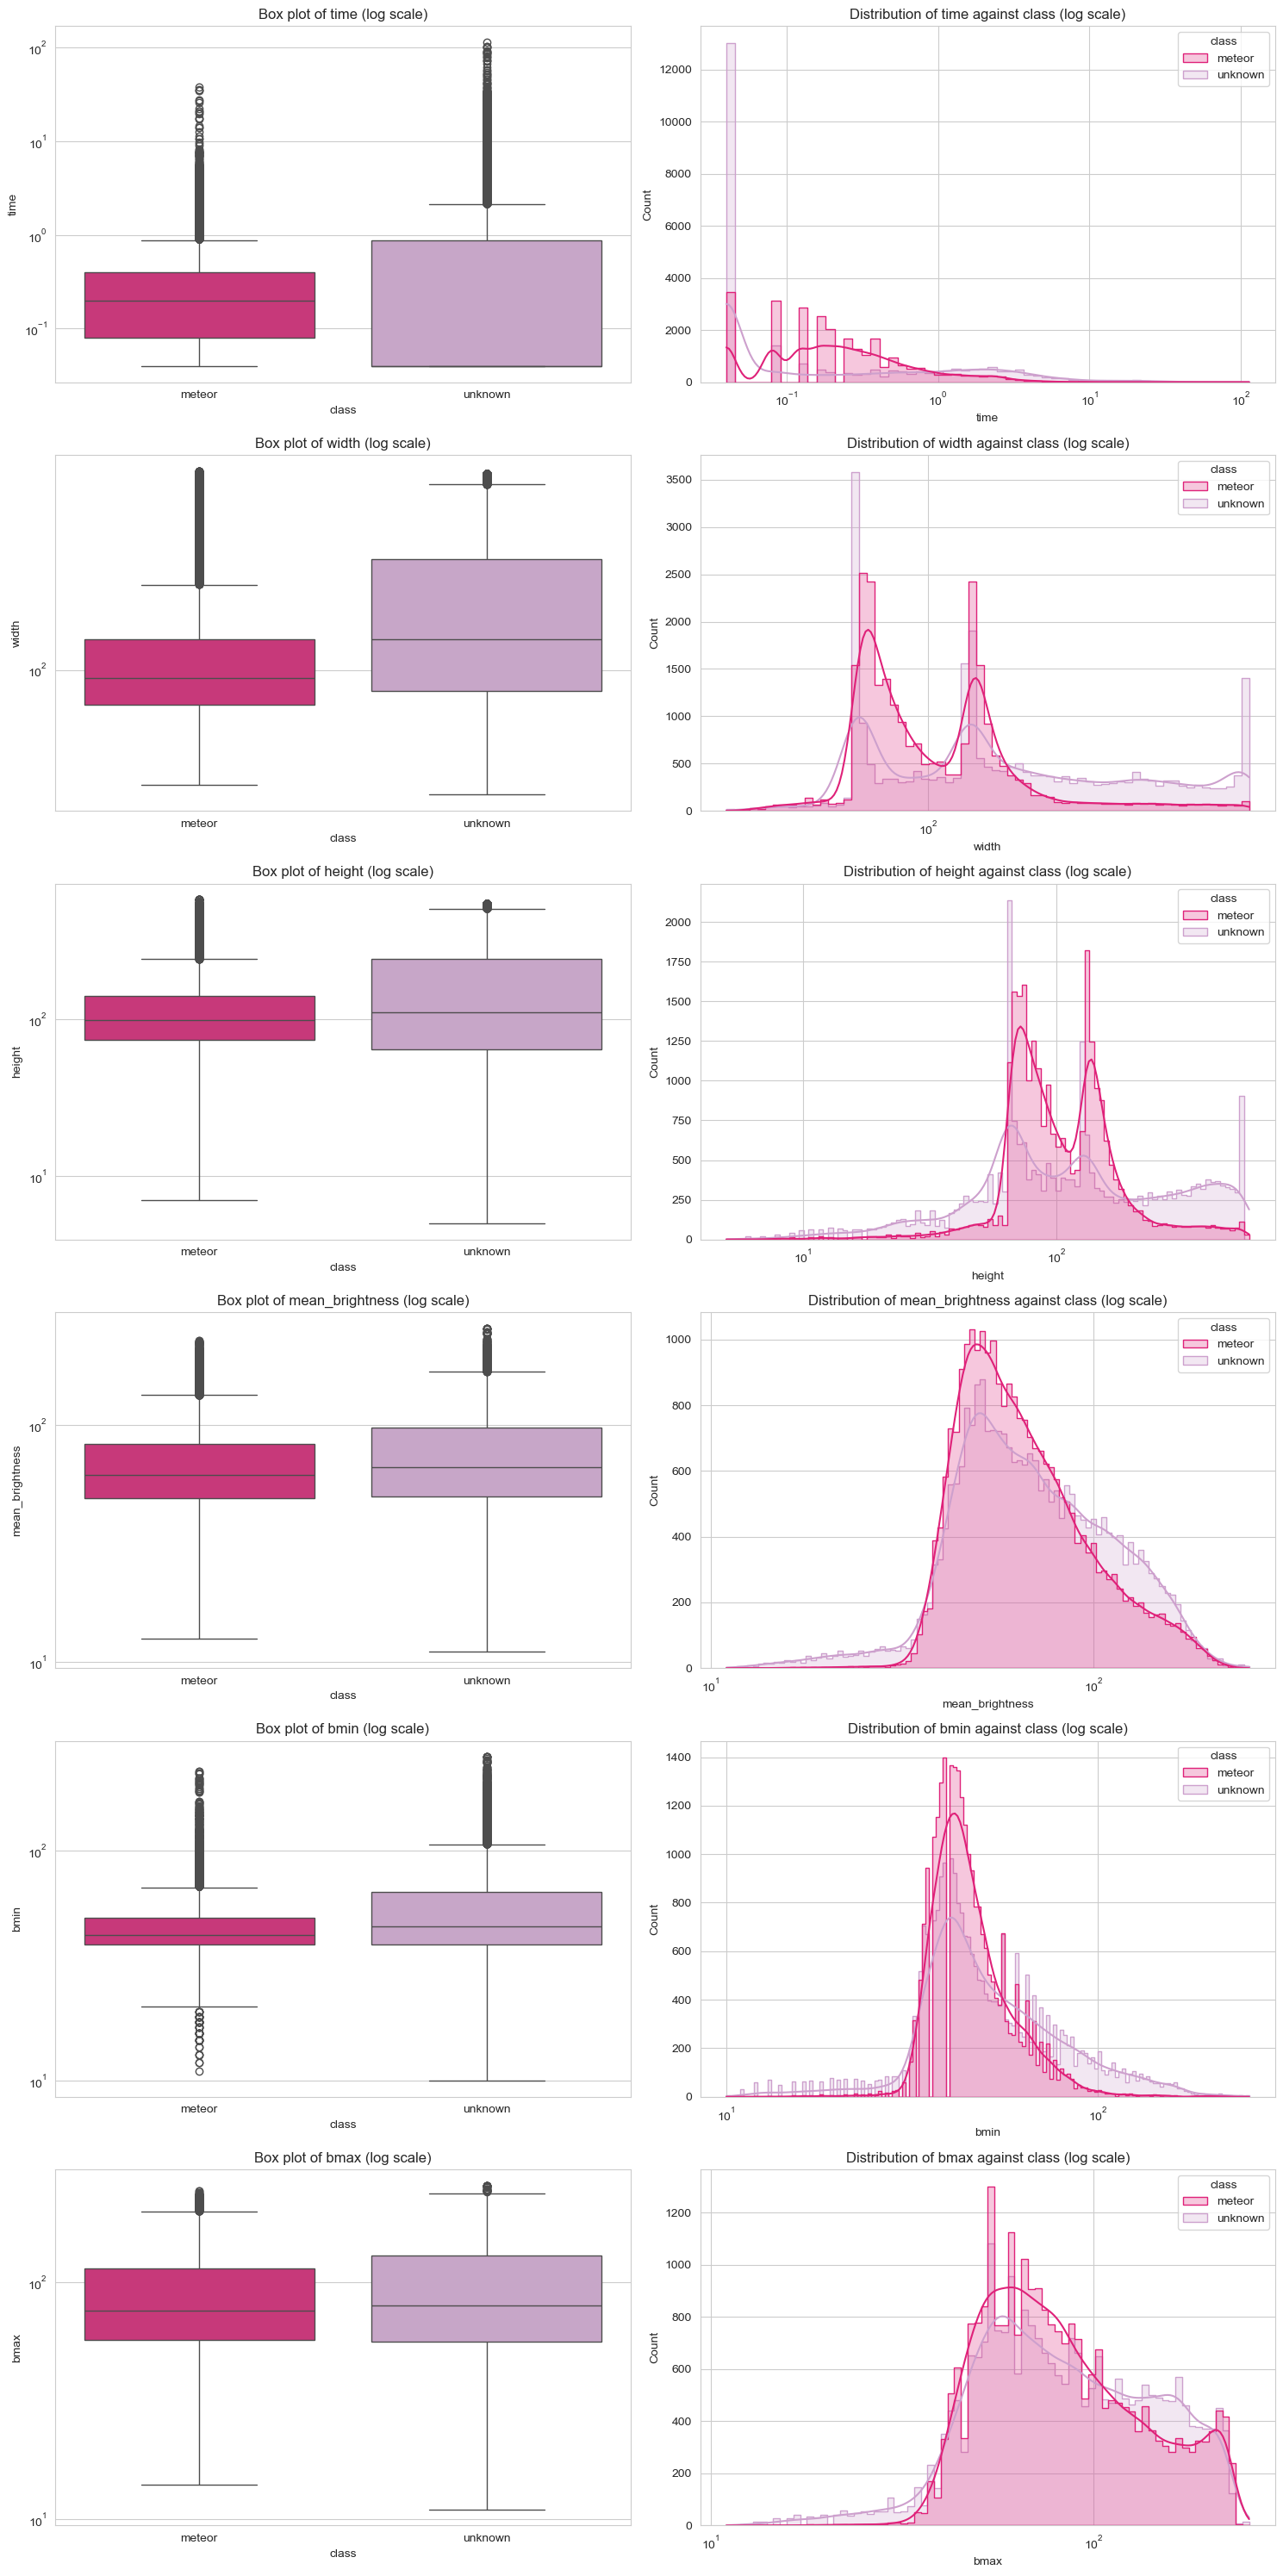

In [12]:
features_df_temp = features_df.copy(deep=True)
numerical_variables = ["time", "width", "height", "mean_brightness", "bmin", "bmax"]

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Determine the number of rows and columns for the subplot grid
num_vars = len(numerical_variables)
cols = 2  # Two plots for each variable: boxplot and distribution plot
rows = num_vars  # One row for each variable

# Create a figure
fig, axs = plt.subplots(rows, cols, figsize=(15, 5*rows))


# Box plots and distribution plots for numerical variables
for i, column in enumerate(numerical_variables):
    sns.boxplot(x='class', y=column, data=features_df_temp, hue='class', palette=PALETTE, ax=axs[i, 0])
    if i in range(rows): # < 0:
        axs[i, 0].set_yscale('log')
        axs[i, 0].set_title(f'Box plot of {column} (log scale)')
    else:
        sns.boxplot(x='class', y=column, data=features_df_temp, hue='class', palette=PALETTE, ax=axs[i, 0])
        axs[i, 0].set_title(f'Box plot of {column}')

    if i in range(rows): # < 0: 
        sns.histplot(data=features_df_temp, x=column, hue='class', log_scale=(True, False), palette=PALETTE, kde=True, element='step', ax=axs[i, 1])
        axs[i, 1].set_title(f'Distribution of {column} against class (log scale)')
    else:
        sns.histplot(data=features_df_temp, x=column, hue='class', palette=PALETTE, kde=True, element='step', ax=axs[i, 1])
        axs[i, 1].set_title(f'Distribution of {column} against class')

# Adjust layout
plt.tight_layout()
plt.show()

C:\Users\auror\AppData\Local\Temp\ipykernel_19368\212508114.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([months_map[int(t.get_text())] for t in ax.get_xticklabels()], rotation=30, ha='right')


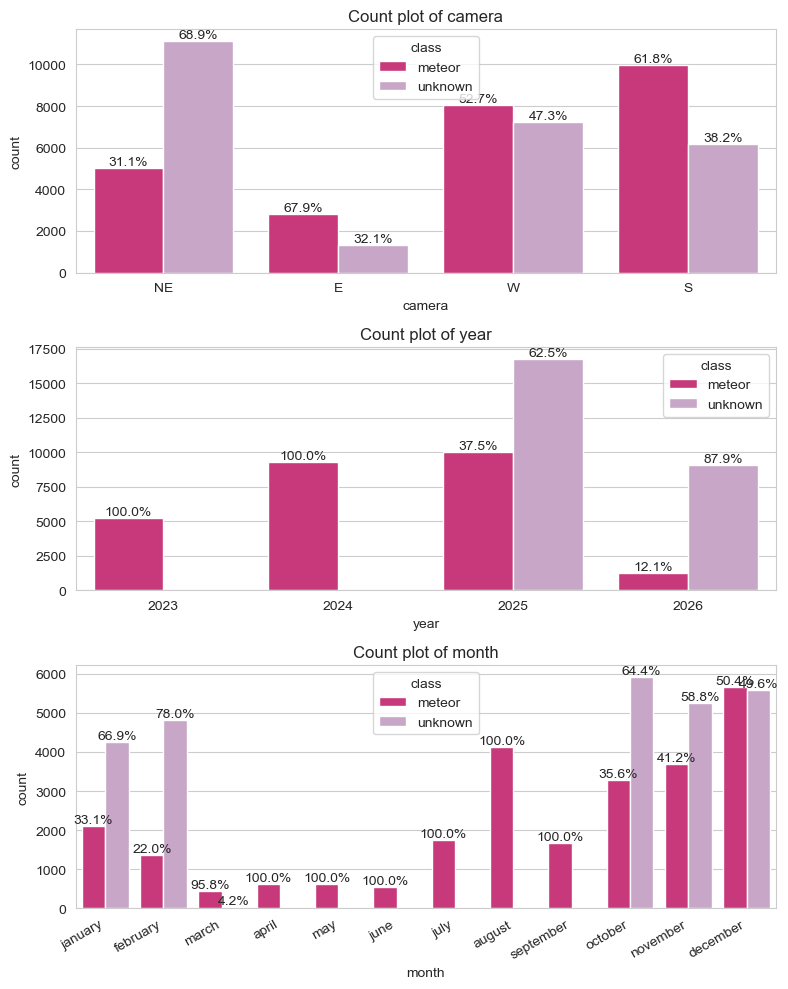

In [13]:
features_df_temp = features_df.copy(deep=True)
features = ["camera", "year", "month"]

sns.set_style("whitegrid")

fig, axs = plt.subplots(len(features), 1, figsize=(8, 10))

for i, column in enumerate(features):

    ax = axs[i]

    # Draw countplot
    sns.countplot(
        data=features_df_temp,
        x=column,
        hue='class',
        palette=PALETTE,
        ax=ax
    )

    ax.set_title(f'Count plot of {column}')
    if column == "month":
        ax.set_xticklabels([months_map[int(t.get_text())] for t in ax.get_xticklabels()], rotation=30, ha='right')

    # Total counts per category
    total_per_category = features_df_temp[column].value_counts()

    # Extract tick labels as strings
    ticklabels = [t.get_text() for t in ax.get_xticklabels()]

    # Convert tick labels back to the column dtype
    if column == 'month':
        reverse_months_map = {v: k for k, v in months_map.items()}
        ticklabels_casted = [reverse_months_map[t] for t in ticklabels]
    elif features_df_temp[column].dtype.kind in "iuf":   # numeric
        ticklabels_casted = [int(t) for t in ticklabels]
    else:
        ticklabels_casted = ticklabels

    # Add percentage labels
    for container in ax.containers:
        labels = []
        for bar in container:
            height = bar.get_height()

            if height == 0:
                labels.append("0%")
                continue

            # Find nearest tick index
            bar_center = bar.get_x() + bar.get_width() / 2
            idx = int(round(bar_center))

            if idx < 0 or idx >= len(ticklabels_casted):
                labels.append("")
                continue

            category = ticklabels_casted[idx]

            total = total_per_category.get(category, 0)

            pct = 100 * height / total if total > 0 else 0
            labels.append(f"{pct:.1f}%")

        ax.bar_label(container, labels=labels, label_type='edge')

plt.tight_layout()
plt.show()


C:\Users\auror\AppData\Local\Temp\ipykernel_19368\1499576217.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([months_map[int(t.get_text())] for t in ax.get_xticklabels()], rotation=30, ha='right')


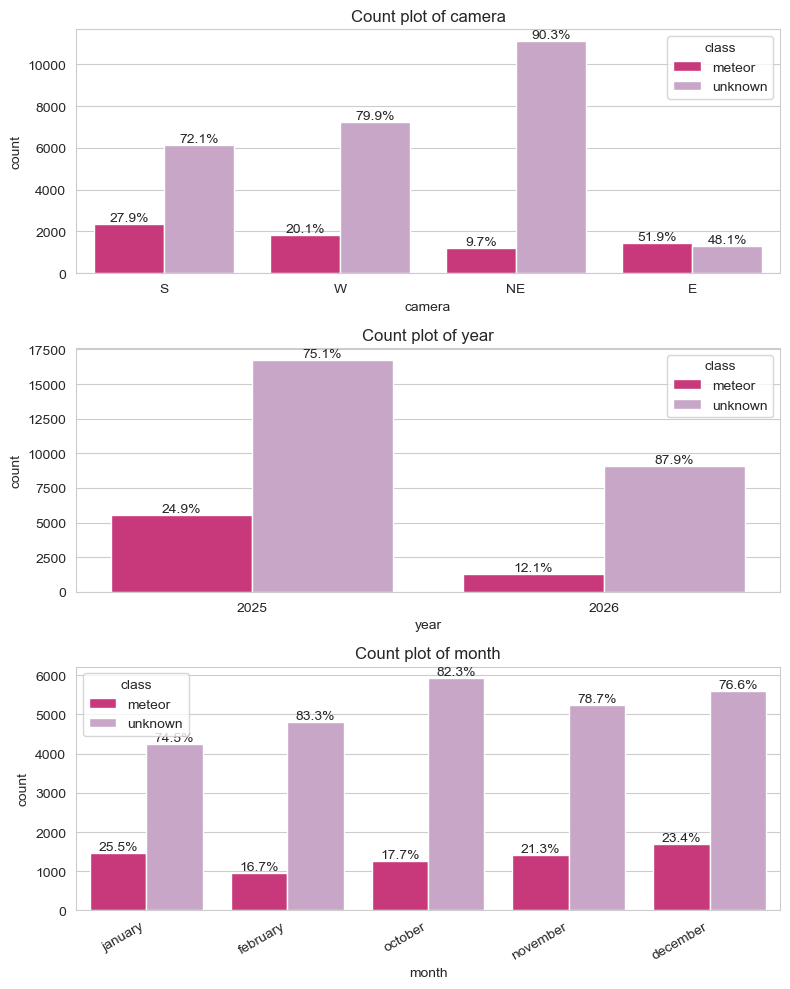

In [14]:
df = features_df.copy(deep=True)
features = ["camera", "year", "month"]

df = df[features + ['class']]
df = df[(df['year'] >= 2025) & (df['month'].isin([10,11,12,1,2]))]


sns.set_style("whitegrid")

fig, axs = plt.subplots(len(features), 1, figsize=(8, 10))

for i, column in enumerate(features):

    ax = axs[i]

    # Draw countplot
    sns.countplot(
        data=df,
        x=column,
        hue='class',
        palette=PALETTE,
        ax=ax
    )

    ax.set_title(f'Count plot of {column}')    
    if column == "month":
        ax.set_xticklabels([months_map[int(t.get_text())] for t in ax.get_xticklabels()], rotation=30, ha='right')

    # Total counts per category
    total_per_category = df[column].value_counts()

    # Extract tick labels as strings
    ticklabels = [t.get_text() for t in ax.get_xticklabels()]

    # Convert tick labels back to the column dtype
    if column == 'month':
        reverse_months_map = {v: k for k, v in months_map.items()}
        ticklabels_casted = [reverse_months_map[t] for t in ticklabels]
    elif df[column].dtype.kind in "iuf":   # numeric
        ticklabels_casted = [int(t) for t in ticklabels]
    else:
        ticklabels_casted = ticklabels

    # Add percentage labels
    for container in ax.containers:
        labels = []
        for bar in container:
            height = bar.get_height()

            if height == 0:
                labels.append("0%")
                continue

            # Find nearest tick index
            bar_center = bar.get_x() + bar.get_width() / 2
            idx = int(round(bar_center))

            if idx < 0 or idx >= len(ticklabels_casted):
                labels.append("")
                continue

            category = ticklabels_casted[idx]

            total = total_per_category.get(category, 0)

            pct = 100 * height / total if total > 0 else 0
            labels.append(f"{pct:.1f}%")

        ax.bar_label(container, labels=labels, label_type='edge')

plt.tight_layout()
plt.show()


C:\Users\auror\AppData\Local\Temp\ipykernel_19368\2518059506.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([months_map[int(t.get_text())] for t in ax.get_xticklabels()], rotation=30, ha='right')


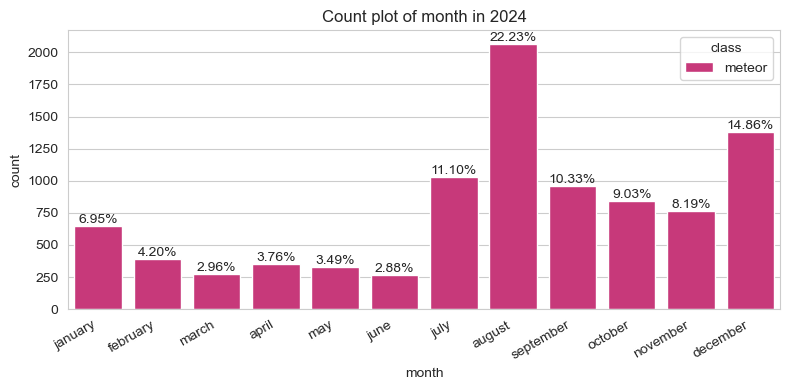

In [15]:
df = features_df.copy(deep=True)

# Keep only needed columns
df = df[["camera", "year", "month", "class"]]

# Filter
df = df[(df['year'] == 2024)]

sns.set_style("whitegrid")

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# Draw countplot
sns.countplot(
    data=df,
    x="month",
    hue="class",
    palette=PALETTE,
    ax=ax
)

ax.set_title("Count plot of month in 2024")
if column == "month":
    ax.set_xticklabels([months_map[int(t.get_text())] for t in ax.get_xticklabels()], rotation=30, ha='right')

# Add raw count labels
total = 0
for container in ax.containers:
    total += sum([int(bar.get_height()) for bar in container])

for container in ax.containers:
    labels = [f"{int(bar.get_height())/total*100:.2f}%" for bar in container]
    ax.bar_label(container, labels=labels, label_type='edge')

plt.tight_layout()
plt.show()


## Correlation Matrix

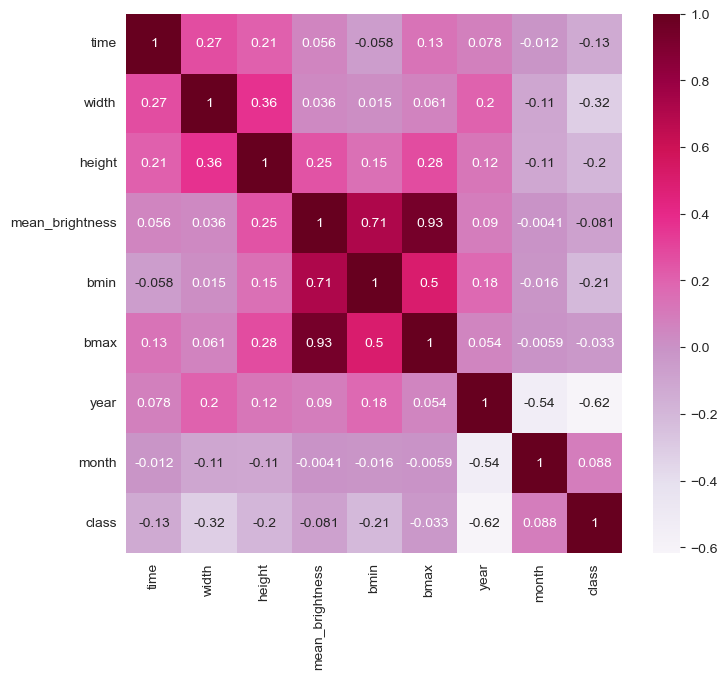

In [16]:
features_df_temp['class'] = (
    features_df_temp['class']
    .map({'meteor': 1, 'unknown': 0})
    .astype(float)
)

corr = features_df_temp[numerical_variables + ['year', 'month', 'class']].corr()

plt.figure(figsize=(8,7))
sns.heatmap(corr, cmap=sns.color_palette('PuRd', as_cmap=True), annot=True)
plt.show()


## Results dataset

In [48]:
# Load
df_test = pd.read_csv("data/dataset_test.csv", sep=";")
df_labeled = pd.read_csv("data/test_set_labels.csv", sep=";")

# Set index to filename for both to align them
df_test.set_index("filename", inplace=True)
df_labeled.set_index("filename", inplace=True)

# 1. Convert 'unknown' to NaN (the 'holes' we want to fill)
df_test['class'] = df_test['class'].replace('unknown', np.nan)

# 2. Fill ONLY the NaN holes using df_labeled
# This will NOT overwrite 'meteor' because 'meteor' is not NaN
df_test['class'] = df_test['class'].fillna(df_labeled['class'])

# 3. Clean up
df_test_labeled = df_test.reset_index()

# Verify
print("Unique classes after merging:", df_test_labeled['class'].unique())
df_test_labeled.sort_values(by="filename", ascending=True, inplace=True)
df_test_labeled.head()

df_test_labeled.to_csv("data/dataset_test_labeled.csv", index=False, sep=";")

Unique classes after merging: ['meteor' 'water_drop' 'cosmic_ray' 'artificial_lights' 'christmas_lights'
 'clouds/background' 'iridium' 'stars' 'camera_artifact' 'airplane'
 'lightning' 'bird' 'satellite' 'insect']


C:\Users\auror\AppData\Local\Temp\ipykernel_10340\4254513771.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdPu")        # or "RdPu_r" if you want darkest = largest


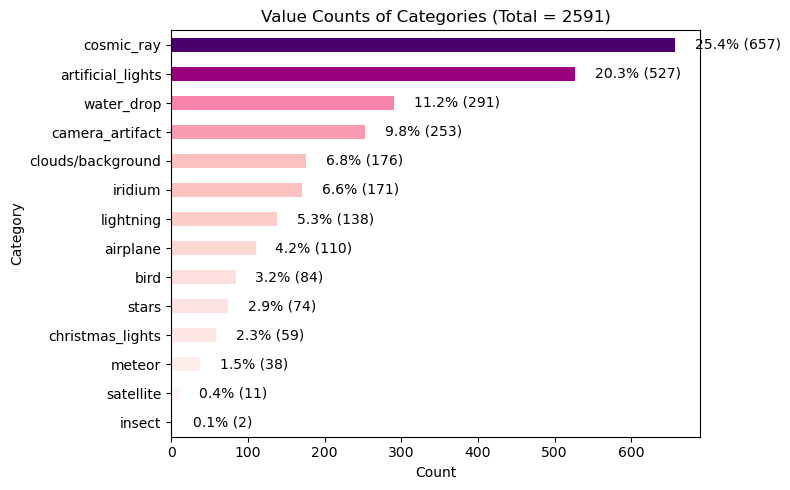

In [14]:
import matplotlib.cm as cm
import matplotlib.colors as colors

counts = df_test_labeled["class"].value_counts().sort_values(ascending=True)
total = counts.sum()
percentages = counts / total * 100

plt.figure(figsize=(8, 5))

# --- NEW: create colors based on bar length ---
values = counts.values
norm = colors.Normalize(vmin=values.min(), vmax=values.max())
cmap = cm.get_cmap("RdPu")        # or "RdPu_r" if you want darkest = largest
bar_colors = cmap(norm(values))

# Horizontal bar plot with custom colors
counts.plot(kind='barh', color=bar_colors)

# Add percentage labels to each bar
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(count + total*0.01, i, f"{pct:.1f}% ({count})", va='center')

plt.xlabel('Count')
plt.ylabel('Category')
plt.title(f'Value Counts of Categories (Total = {total})')

plt.tight_layout()
plt.show()

## Averaged images

In [5]:
def plot_image_grid(images, captions, rows=3, cols=5, figsize=(12, 8)):
    """
    images: list of image arrays (grayscale or RGB)
    captions: list of strings, same length as images
    """
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()

    for ax, img, cap in zip(axes, images, captions):
        ax.imshow(img, cmap='gray')
        ax.set_title(cap, fontsize=10)
        ax.axis('off')

    # Hide any unused axes (if images < rows*cols)
    for ax in axes[len(images):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [6]:
import os
import re
from PIL import Image

images = []
captions = []
images_crop = []
captions_crop = []
for image in os.listdir("average_images_per_class"):
    amount = ""
    if image.endswith("_crop.png"):
        match = re.match(r"^(.*?)(_avg)(\d+)(_crop\.png)$", image)
        if match:
            prefix = match.group(1)
            amount = match.group(3)
        images_crop.append(Image.open(f"average_images_per_class/{image}"))
        captions_crop.append(f"{prefix}_crop ({amount})")
    else:
        match = re.match(r"^(.*?)(_avg)(\d+)(\.png)$", image)
        if match:
            prefix = match.group(1)
            amount = match.group(3)
        images.append(Image.open(f"average_images_per_class/{image}"))
        captions.append(f"{prefix} ({amount})")

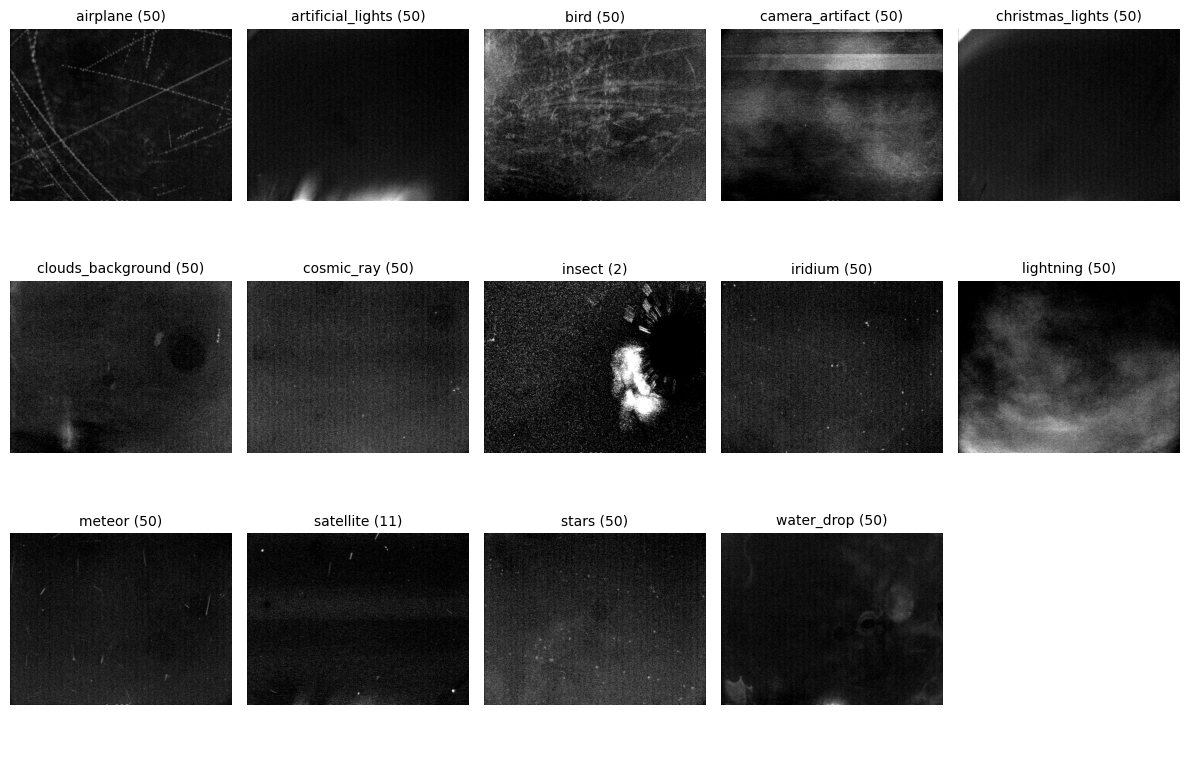

In [7]:
plot_image_grid(images, captions)

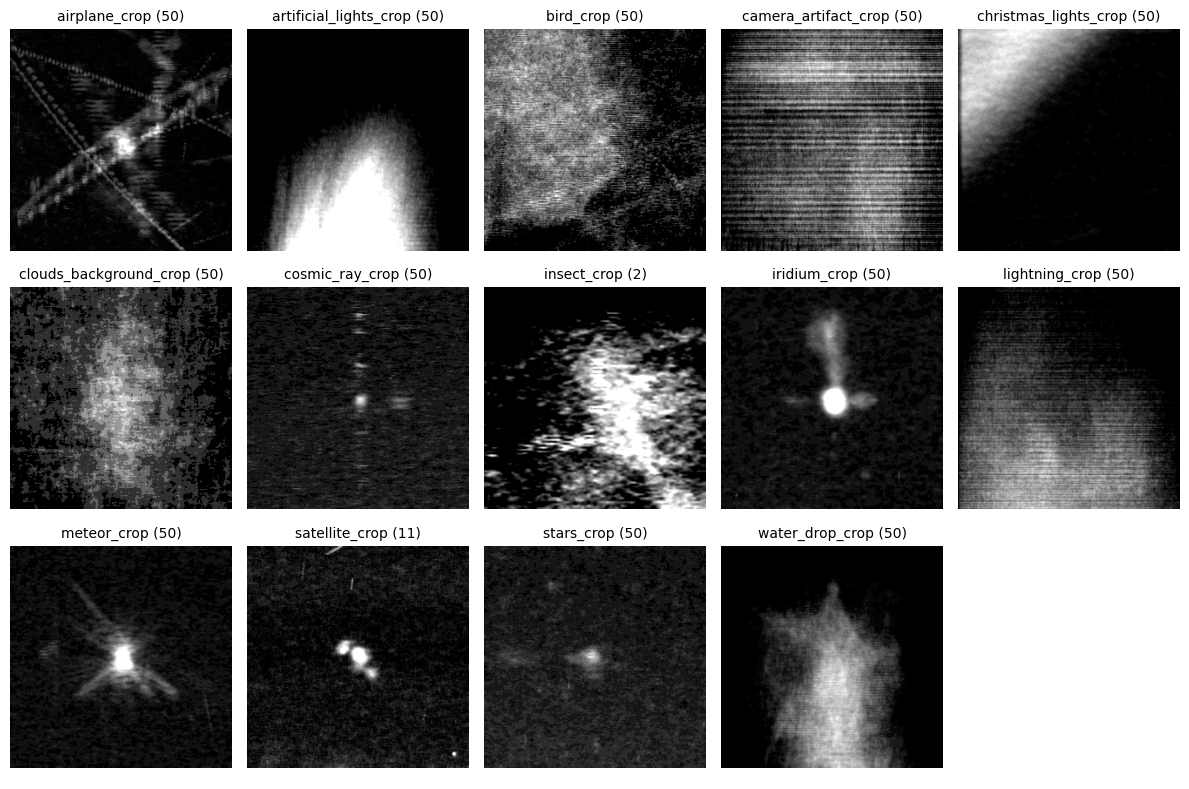

In [8]:
plot_image_grid(images_crop, captions_crop)